In [3]:
import pandas as pd 
from datasets import load_dataset
import re
from upsetplot import UpSet
from collections import Counter
import numpy as np


/home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Binary Exploration

In [4]:
GENERATED_DATA_PATH =  "./2_gen_mbj_bandgap/material_generated_samples_database_added_tr_check_added.csv"
df_gen = pd.read_csv(GENERATED_DATA_PATH)

In [19]:
df_gen.head()

,prompt,response,formula,expected_prop_val,after_alignn_prop_val,gen_material_str,gen_material_cif,Alexandria,Alexandria_id,MC3D,MC3D_id,OQMD,OQMD_id,JARVIS,JARVIS_id,MaterialsProject,MaterialsProject_id,Match_Found,Matched_Formula
0,Below is a description of a superconductor mat...,Below is a description of a superconductor mat...,SiH,3.711,NaN,3.9 3.9 5.0\n90 90 120\nSi\n0.33 0.67 0.93\nSi...,# generated using pymatgen\ndata_SiH\n_symmetr...,1.0,agm002086366,1.0,50707.0,11.0,4067700.0,2.0,dft_2d_JVASP-6808,1.0,mp-29803,True,SiH
1,Below is a description of a superconductor mat...,['Below is a description of a superconductor m...,HO,3.114,NaN,3.3 3.3 3.3\n90 90 90\nH\n0.00 0.00 0.00\nH\n0...,# generated using pymatgen\ndata_H2O2\n_symmet...,NaN,NaN,2.0,4687.0,8.0,4384824.0,8.0,dft_3d_JVASP-12577,2.0,mp-23939,True,HO
2,Below is a description of a superconductor mat...,['Below is a description of a superconductor m...,HC,3.811,NaN,3.7 3.7 3.7\n109 109 109\nH\n0.39 0.00 0.50\nH...,# generated using pymatgen\ndata_HC\n_symmetry...,2.0,agm003163144,2.0,232425.0,12.0,4482003.0,13.0,dft_3d_JVASP-101785,4.0,mp-995197,True,HC
3,Below is a description of a superconductor mat...,['Below is a description of a superconductor m...,HN,4.062,NaN,3.4 3.4 3.4\n109 109 108\nH\n0.75 0.75 -0.00\n...,# generated using pymatgen\ndata_HN\n_symmetry...,1.0,agm003240882,3.0,278619.0,13.0,4468545.0,5.0,dft_3d_JVASP-134971,4.0,mp-720515,NaN,NaN
4,Below is a description of a superconductor mat...,['Below is a description of a superconductor m...,AlH,3.261,NaN,3.6 3.6 5.1\n90 90 90\nAl\n0.50 0.50 0.39\nAl\...,# generated using pymatgen\ndata_AlH\n_symmetr...,NaN,NaN,NaN,NaN,8.0,4480989.0,3.0,dft_3d_JVASP-139255,NaN,NaN,True,AlH


In [20]:
colums = ["Alexandria", "MC3D", "OQMD", "JARVIS", "MaterialsProject","Match_Found"]
db_data = df_gen[colums]
db_data['Exist in Training Data'] = db_data['Match_Found'].map({True: 1, np.nan: 0})
db_data = db_data.drop(columns=['Match_Found'])


/tmp/ipykernel_1553026/3309570011.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  db_data['Exist in Training Data'] = db_data['Match_Found'].map({True: 1, np.nan: 0})


/home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth

<Figure size 16000x16000 with 0 Axes>

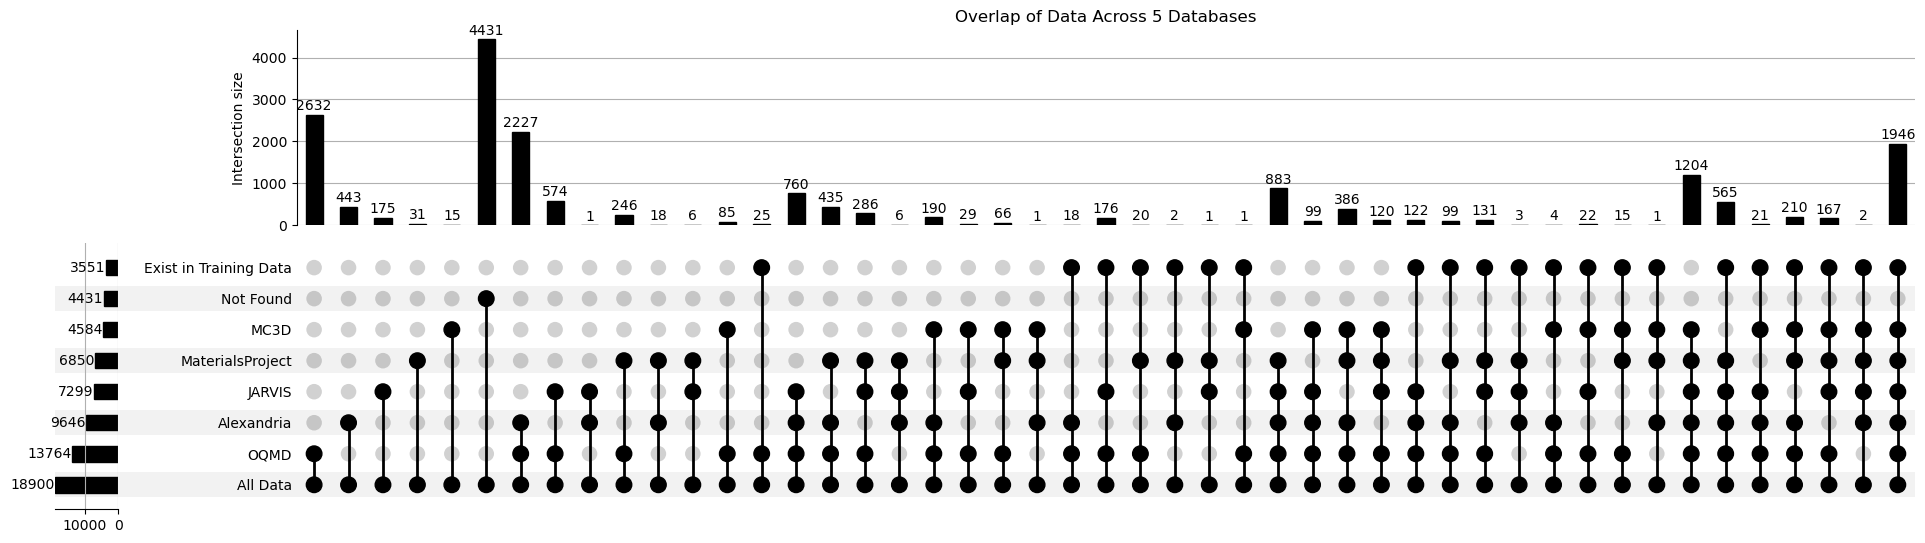

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from upsetplot import UpSet, from_contents

idx_dict = {col: db_data.index[db_data[col] > 0].tolist() for col in db_data.columns}

all_data = df_gen.index.tolist()

all_data_set = set(all_data)  # Convert all_data to a set
idx_dict_values_set = set(sum(idx_dict.values(), []))  # Flatten and convert idx_dict values to a set

idx_dict['Not Found'] = list(all_data_set - idx_dict_values_set)

idx_dict['All Data'] = all_data


# UpSet Plot (better for 3+ sets)
upset_data = from_contents(idx_dict)


plt.figure(figsize=(16, 16), dpi = 1000)
UpSet(upset_data, show_counts=True).plot()
plt.title("Overlap of Data Across 5 Databases")
plt.show()


In [114]:
df_unique = df_gen.loc[sorted(idx_dict['unique_data'])]
df_unique.to_csv(f"./2_gen_mbj_bandgap/material_generated_unique.csv", index=False)

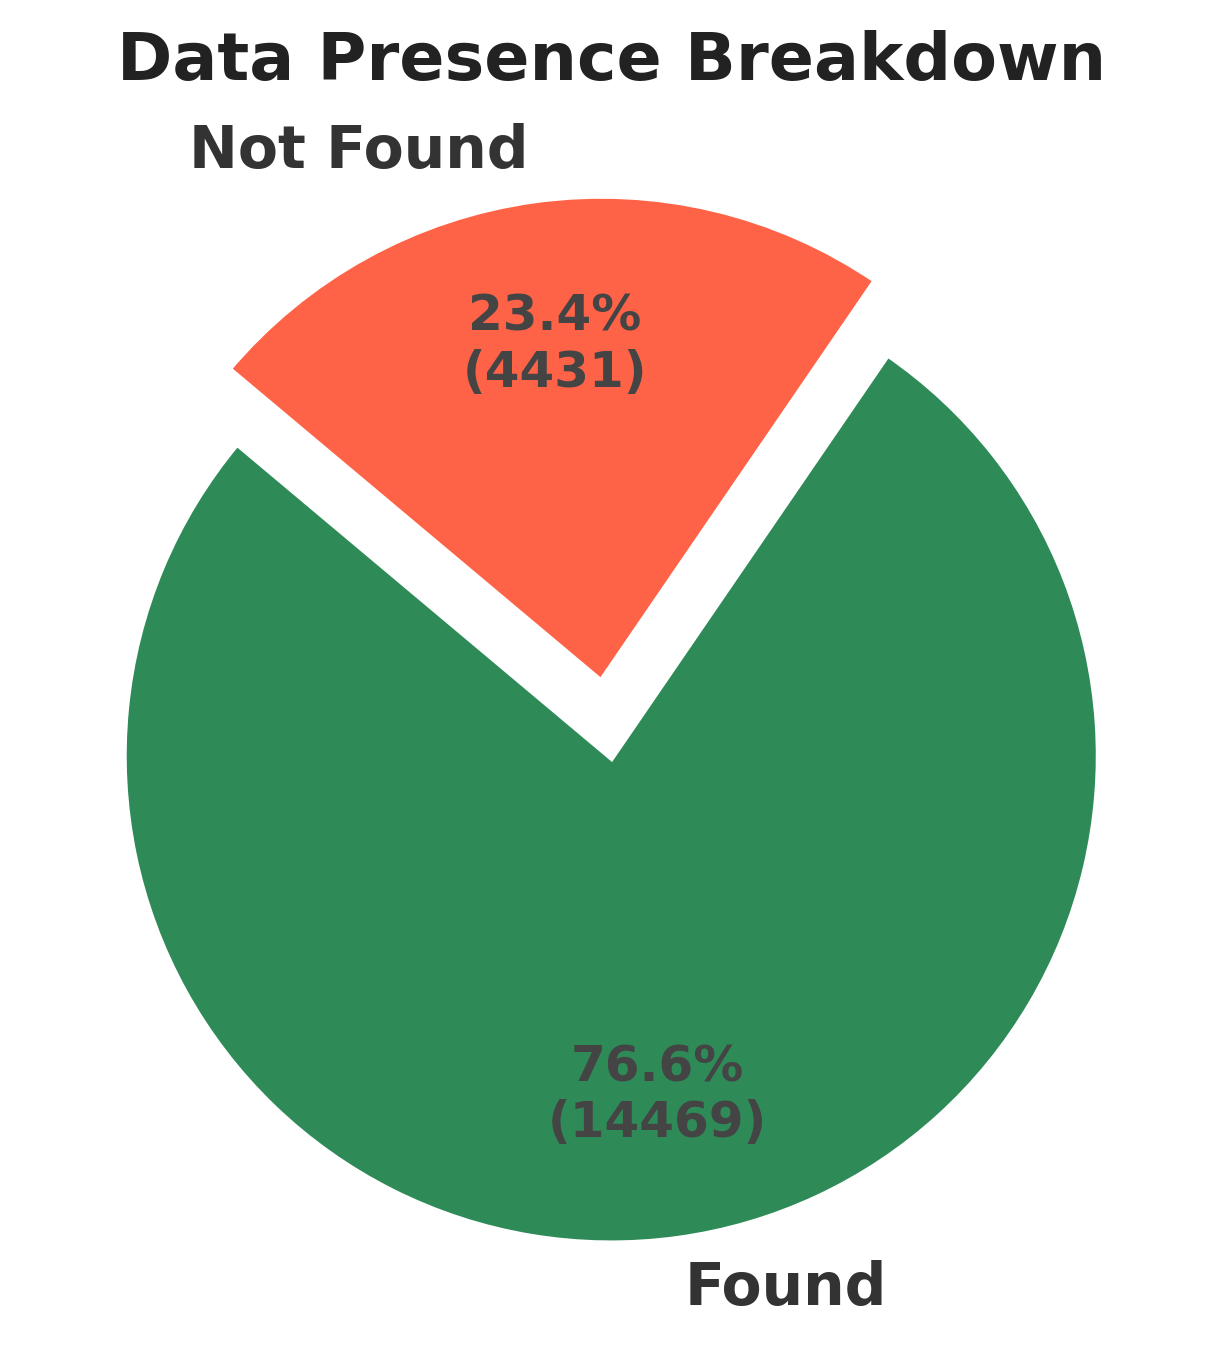

In [46]:
import matplotlib.pyplot as plt

# Data to plot
labels = ['Found', 'Not Found']
sizes = [len(idx_dict_values_set), len(list(all_data_set - idx_dict_values_set))]
colors = ['#2E8B57', '#FF6347']  # Deep green & tomato red for a rich contrast

# Create a high-quality figure
plt.figure(figsize=(5, 5), dpi=300)  

# Pie chart with refined aesthetics
wedges, texts, autotexts = plt.pie(
    sizes, labels=labels, colors=colors, startangle=140, 
    autopct=lambda pct: f'{pct:.1f}%\n({round(pct/100.*sum(sizes))})',
    wedgeprops={'edgecolor': '#ffffff', 'linewidth': 2, 'antialiased': True},  # White edges for separation
    textprops={'fontsize': 14, 'fontweight': 'bold', 'color': '#333333'},  # Dark gray text for modern look
    pctdistance=0.7,  # Better spacing for percentages
    labeldistance=1.1,  # More breathing space for labels
    explode=(0.05, 0.1),  # Slight explosion for emphasis
    shadow=False  # No unnecessary 3D effects
)

# Make labels slightly larger
for text in texts:
    text.set_fontsize(14)

# Slightly increase percentage text size
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_color('#444444')  # Darker gray for a softer look

# Equal aspect ratio for a perfect circle
plt.axis('equal')

# Elegant title
plt.title("Data Presence Breakdown", fontsize=16, fontweight='bold', color='#222222', pad=15)

# Display the chart
plt.show()


# Ternary Exploration

In [5]:
ternary_main_path = "/home/jipengsun/LLM_Atom_Gen/2_gen_mbj_bandgap/material_generated_samples_ternary.csv"
_ternary_1_path = "/home/jipengsun/LLM_Atom_Gen/2_gen_mbj_bandgap/material_generated_samples_ternary_onlyelementlist1.csv"
_ternary_2_path = "/home/jipengsun/LLM_Atom_Gen/2_gen_mbj_bandgap/material_generated_samples_ternary_onlyelementlist1 copy.csv"
_ternary_3_path = "/home/jipengsun/LLM_Atom_Gen/2_gen_mbj_bandgap/material_generated_samples_ternary_onlyelementlist.csv"

In [ ]:
ternary_main = pd.read_csv(ternary_main_path)
ternary_1 = pd.read_csv(_ternary_1_path)
ternary_2 = pd.read_csv(_ternary_2_path)
ternary_3 = pd.read_csv(_ternary_3_path)
len(ternary_main), len(ternary_1), len(ternary_2), len(ternary_3)


(204887, 58381, 47, 74088)

In [30]:
merged_df = pd.concat([ternary_main, ternary_1, ternary_2, ternary_3], ignore_index=True)
len(merged_df)
save_path = "/home/jipengsun/LLM_Atom_Gen/2_gen_mbj_bandgap/material_generated_samples_ternary_all.csv"
merged_df.to_csv(save_path, index=False)
# Check for duplicates

In [33]:
merged_df.head()

,prompt,response,formula,expected_prop_val,after_alignn_prop_val,gen_material_str,gen_material_cif
0,Below is a description of a superconductor mat...,Below is a description of a superconductor mat...,SiH,3.196,NaN,3.9 3.9 5.0\n90 90 120\nSi\n0.33 0.67 0.93\nSi...,# generated using pymatgen\ndata_SiH\n_symmetr...
1,Below is a description of a superconductor mat...,['Below is a description of a superconductor m...,SiHO,3.720,NaN,3.6 4.9 2.8\n90 90 123\nSi\n0.76 0.86 0.00\nH\...,# generated using pymatgen\ndata_SiHO\n_symmet...
2,Below is a description of a superconductor mat...,['Below is a description of a superconductor m...,SiHC,4.809,NaN,3.6 3.6 4.4\n90 90 120\nSi\n0.33 0.67 0.02\nH\...,# generated using pymatgen\ndata_SiHC\n_symmet...
3,Below is a description of a superconductor mat...,['Below is a description of a superconductor m...,SiHN,2.794,NaN,3.4 3.4 5.1\n90 90 120\nSi\n0.33 0.67 0.46\nH\...,# generated using pymatgen\ndata_SiHN\n_symmet...
4,Below is a description of a superconductor mat...,['Below is a description of a superconductor m...,AlSiH,3.267,NaN,4.1 4.1 4.1\n60 60 60\nAl\n0.00 0.00 0.00\nSi\...,# generated using pymatgen\ndata_AlSiH\n_symme...


In [35]:
def swap_ternary_formula(formula):
    # Extract element symbols and their counts
    elements = re.findall(r"[A-Z][a-z]?\d*", formula)
    print(elements)
    if len(elements) == 3:
        # Swap first and third elements
        elements[0], elements[2] = elements[2], elements[0]
        
        swapped_formula = "".join(elements)
        return swapped_formula
    if len(elements) == 2:
        elements = re.findall(r"[A-Z][a-z]?\d*", formula)  # Extract element-symbol + count
        swapped_formula = "".join(reversed(elements))  # Reverse order
        return swapped_formula
    else:
        return formula

print(swap_ternary_formula('SiH'))  # Output: PO4FeLi
print(swap_ternary_formula('NaClO3'))   # Output: O3ClNa


['Si', 'H']
HSi
['Na', 'Cl', 'O3']
O3ClNa
